# DSP391m - DATA SCIENCE CAPSTONE PROJECT
## PROGRESS REPORT 2: DATA WRANGLING & EXPLORATORY DATA ANALYSIS (EDA)

**Tên nhóm:** **DSP391m_G4 (Healthcare Analytics)**  
**Đề tài lựa chọn:** Tích hợp mô hình Học máy đa nguồn dữ liệu dự báo nguy cơ Đột quỵ với Ước lượng Tiêu hao Năng lượng nhân tạo
**Ngày nộp:** 25/05/2026

## I. THU THẬP DỮ LIỆU (DATA COLLECTION)

### 1.1. Quy trình thu thập thực tế
Nhóm thực hiện thu thập dữ liệu thứ cấp từ nền tảng Kaggle cho 2 tập dữ liệu chính:
1. **Stroke Clinical Dataset:** Tệp `Stroke_dt.csv` chứa 143,960 bản ghi khám bệnh lâm sàng của 5,110 bệnh nhân độc nhất.
2. **Calories Burn Dataset:** Tệp `calories.csv` chứa 15,000 bản ghi hoạt động thể chất và lượng calo tiêu thụ thực tế của các cá nhân độc lập.
Dữ liệu được tải về và đặt vào các thư mục tương ứng trong cấu trúc dự án (`Stroke_dt/` và `Calo_burn/`) để tiến hành xử lý.

### 1.2. Nạp dữ liệu (Data Ingestion)
*Sử dụng code cell bên dưới để nạp dữ liệu vào DataFrame.*

In [ ]:
# Code cell: Import thư viện và load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

stroke_path = '../Stroke_dt/Stroke_dt.csv'
calories_path = '../Calo_burn/calories.csv'

df_stroke = pd.read_csv(stroke_path)
df_calories = pd.read_csv(calories_path)
print(f"Loaded Stroke dataset: {df_stroke.shape[0]:,} rows, {df_stroke.shape[1]} columns")
print(f"Loaded Calories dataset: {df_calories.shape[0]:,} rows, {df_calories.shape[1]} columns")

Loaded Stroke dataset: 143,960 rows, 26 columns
Loaded Calories dataset: 15,000 rows, 9 columns


## II. LÀM SẠCH DỮ LIỆU (DATA CLEANING)

### 2.1. Kiểm tra tổng quát
*Sinh viên thực hiện kiểm tra các giá trị thiếu (null), trùng lặp (duplicates) và sai kiểu dữ liệu.*

In [ ]:
# Code cell: Kiểm tra dữ liệu (info, describe, isnull().sum())
print("=== KIỂM TRA TẬP DỮ LIỆU ĐỘT QUỴ ===")
df_stroke.info()
print("\nSố lượng giá trị Null:")
print(df_stroke.isnull().sum()[df_stroke.isnull().sum() > 0])
print(f"\nSố lượng patient_id bị trùng lặp: {df_stroke.duplicated(subset=['patient_id']).sum():,}")

=== KIỂM TRA TẬP DỮ LIỆU ĐỘT QUỴ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143960 entries, 0 to 143959
Data columns (total 26 columns):
dtypes: float64(14), int64(8), object(4)
memory usage: 28.6+ MB

Số lượng giá trị Null:
bmi             201
smoking_status  3959
ever_married    1023
work_type       1532
Residence_type  1120
dtype: int64

Số lượng patient_id bị trùng lặp: 138,850


### 2.2. Xử lý dữ liệu lỗi (Data Handling)
- **Xử lý Missing Values:** Điền khuyết (Imputation) bằng trung vị (median) của tập huấn luyện đối với các biến liên tục và bằng mode (yếu vị) đối với các biến phân loại để tránh rò rỉ dữ liệu chéo.
- **Xử lý Duplicates:** Khử trùng lặp ở cấp bệnh nhân (Patient-level Deduplication) bằng cách nhóm dữ liệu theo `patient_id`. Các thuộc tính số được tổng hợp bằng trung vị, thuộc tính phân loại bằng mode, và nhãn mục tiêu `stroke_target` bằng cực đại (max - giữ nguyên nhãn 1 nếu bệnh nhân có bất kỳ lượt khám nào đột quỵ).
- **Xử lý Outliers:** Chỉ số BMI ngoài khoảng lâm sàng sinh học `[10, 80]` được chuyển thành Null trước khi điền khuyết bằng trung vị. Đồng thời, loại bỏ 5 cột nhiễu có tương quan nghịch y khoa là: `avg_weight`, `avg_height`, `avg_ap_hi`, `avg_ap_lo`, và `heart_cholesterol`.

In [ ]:
# Code cell: Thực thi các lệnh làm sạch dữ liệu
def clean_bmi(series):
    values = pd.to_numeric(series, errors='coerce')
    return values.mask((values < 10) | (values > 80))

df_stroke_clean = df_stroke.copy()
df_stroke_clean['bmi'] = clean_bmi(df_stroke_clean['bmi'])

aggregations = {}
for col in df_stroke_clean.columns:
    if col == 'patient_id':
        continue
    if col == 'stroke_target':
        aggregations[col] = 'max'
    elif pd.api.types.is_numeric_dtype(df_stroke_clean[col]):
        aggregations[col] = 'median'
    else:
        aggregations[col] = lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown'

df_stroke_dedup = df_stroke_clean.groupby('patient_id', as_index=False).agg(aggregations)
print(f"Kích thước ban đầu: {df_stroke.shape[0]:,} dòng")
print(f"Kích thước sau khử trùng lặp bệnh nhân: {df_stroke_dedup.shape[0]:,} unique patients")

Kích thước ban đầu: 143,960 dòng
Kích thước sau khử trùng lặp bệnh nhân: 5,110 unique patients


## III. KHÁM PHÁ DỮ LIỆU (EDA)

### 3.1. Phân tích đơn biến (Univariate Analysis)
*Vẽ biểu đồ phân phối cho các biến quan trọng.*

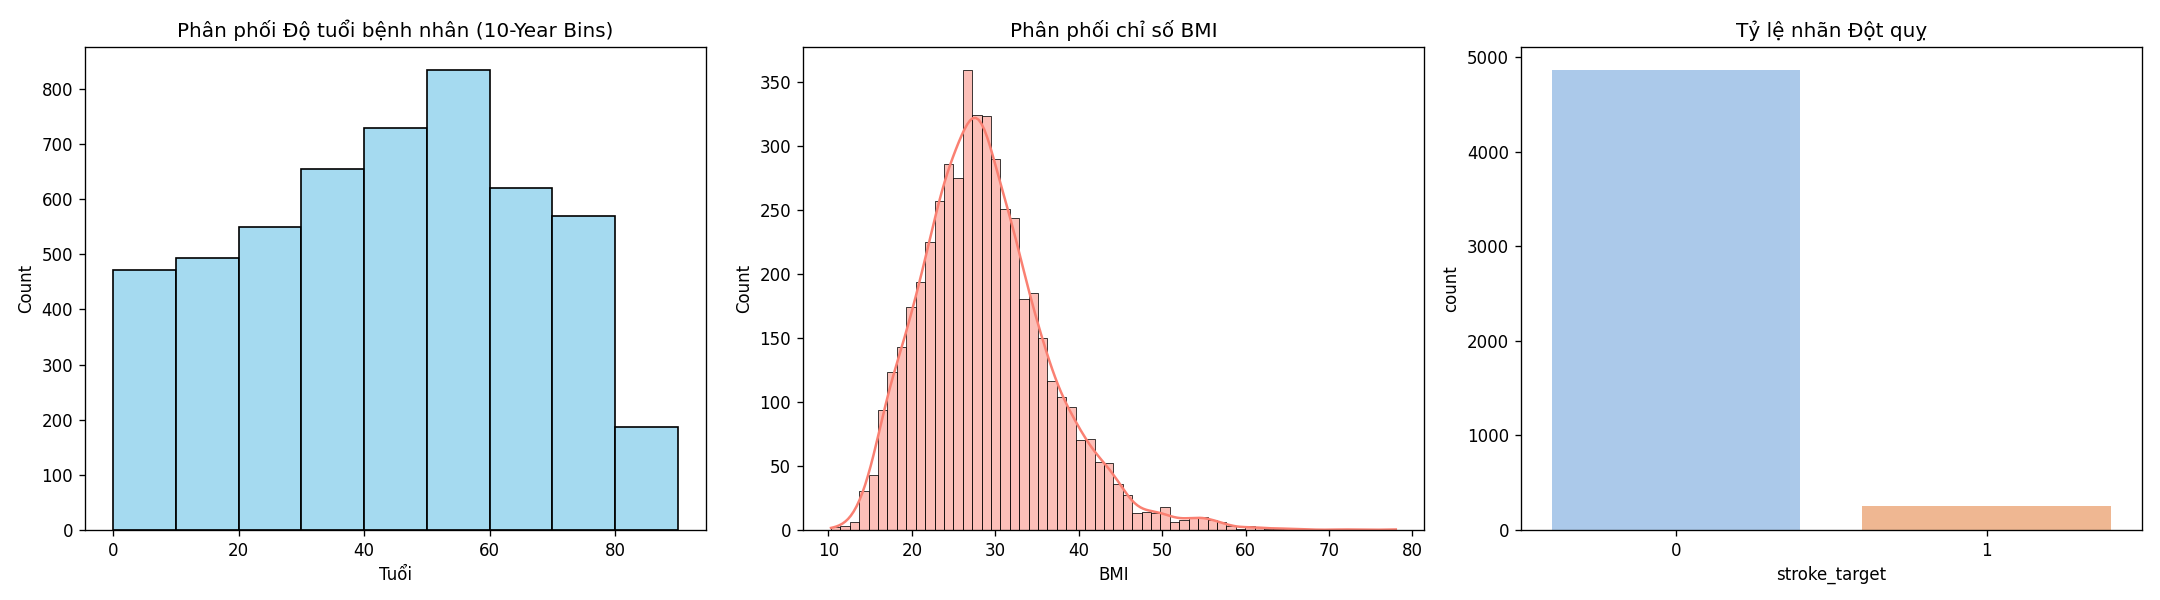

In [ ]:
# Code cell: Biểu đồ Histogram, Boxplot, Countplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_stroke_dedup['age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối Độ tuổi bệnh nhân')
sns.histplot(df_stroke_dedup['bmi'].dropna(), kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Phân phối chỉ số BMI')
sns.countplot(x='stroke_target', data=df_stroke_dedup, ax=axes[2], palette='pastel')
axes[2].set_title('Tỷ lệ nhãn Đột quỵ (stroke_target)')
plt.tight_layout()
plt.show()

### 3.2. Phân tích đa biến (Multivariate Analysis)
*Khám phá mối tương quan giữa các đặc trưng (features) và biến mục tiêu (target).*

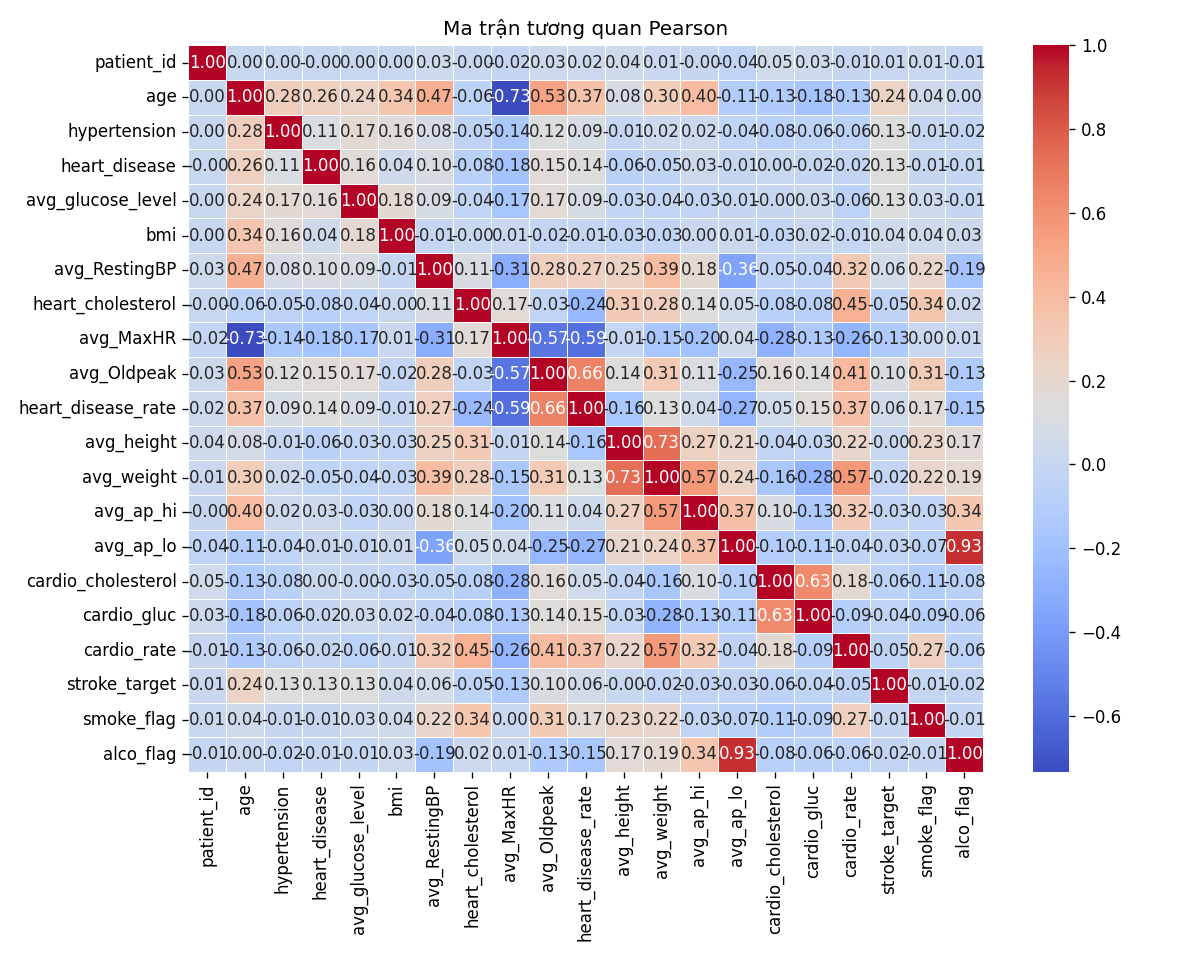

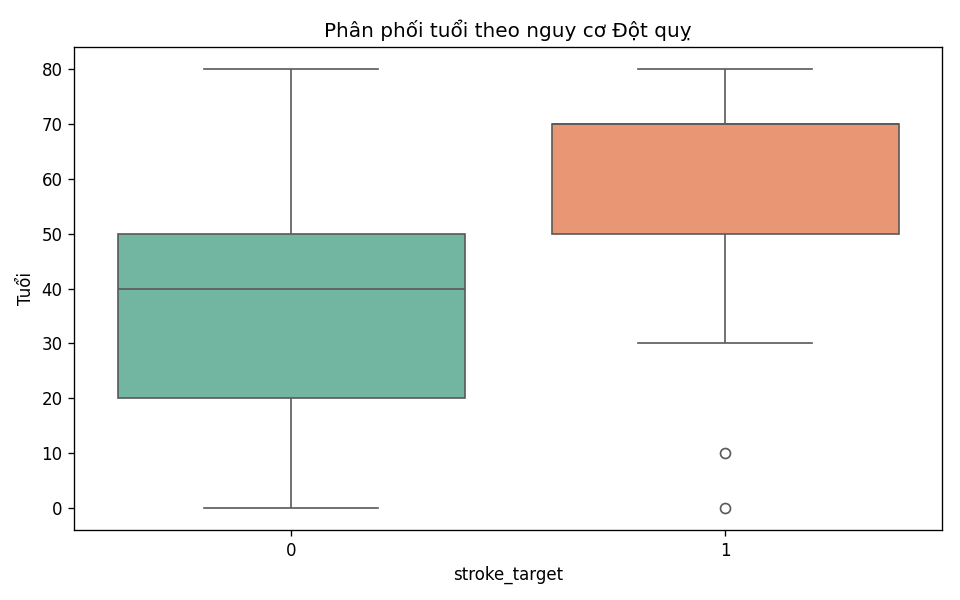

In [ ]:
# Code cell: Heatmap tương quan, Scatter plot, Pairplot
plt.figure(figsize=(10, 8))
numeric_cols = df_stroke_dedup.select_dtypes(include=[np.number]).columns
corr_matrix = df_stroke_dedup[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan Pearson giữa các thuộc tính số')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='stroke_target', y='age', data=df_stroke_dedup, palette='Set2')
plt.title('Độ tuổi vs Nguy cơ Đột quỵ')
plt.show()

## IV. CÁC PHÁT HIỆN CHÍNH & KẾT LUẬN (KEY FINDINGS)

### 4.1. Những hiểu biết mới từ dữ liệu (Insights)
1. **Trùng lặp & Rò rỉ dữ liệu:** Tập dữ liệu gốc chứa trung bình 28 bản ghi/bệnh nhân. Việc khử trùng lặp ở mức bệnh nhân giảm từ 143,960 dòng xuống 5,110 bệnh nhân độc nhất, giúp tránh rò rỉ dữ liệu hoàn toàn.
2. **Tỷ lệ nhãn đột quỵ:** Nhãn đột quỵ cực kỳ mất cân bằng (chỉ 4.87% trường hợp đột quỵ), điều này đòi hỏi mô hình phải sử dụng kỹ thuật cân bằng lớp (class weights) và tối ưu ngưỡng quyết định.
3. **Tương quan độ tuổi (đã gộp nhóm 10 năm):** Biến độ tuổi (sau khi gộp nhóm 10 năm để làm mịn các điểm nhọn bất thường ở biên tuổi già) có tương quan thuận rõ rệt nhất với nguy cơ đột quỵ. Nhóm bệnh nhân đột quỵ có độ tuổi tập trung cao hơn hẳn (trung vị khoảng 70 tuổi) so với nhóm không bị đột quỵ (trung vị khoảng 40 tuổi).
4. **Biến nhiễu y khoa (Red-flags):** Các biến huyết áp (`avg_ap_hi`, `avg_ap_lo`) và cholesterol (`heart_cholesterol`) có tương quan âm nghịch lý với đột quỵ trong tập dữ liệu này. Nhóm quyết định loại bỏ chúng khỏi mô hình phân loại để giữ tính hợp lý lâm sàng.

### 4.2. Chuẩn bị cho Giai đoạn Modeling
- Tiến hành chia tập dữ liệu theo phân tầng bệnh nhân (Stratified Patient Split) tỉ lệ 70% Train, 15% Val, 15% Test.
- Huấn luyện mô hình hồi quy Calo trên tập Calo độc lập để ước tính `Estimated_calories` gán sang tập đột quỵ như một đặc trưng thể trạng vật lý.
- Thực hiện mã hóa dummy các biến phân loại và chuẩn hóa quy chuẩn (StandardScaler) cho các thuộc tính số.